In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle as pkl
from sklearn.model_selection import RandomizedSearchCV, train_test_split

In [3]:
root_path = "./"

In [10]:
combined_features_final_df_train = pd.read_csv(
    root_path + "featurization/featurization_final/combined_features_final_df_train.csv"
)
combined_features_final_df_test = pd.read_csv(
    root_path + "featurization/featurization_final/combined_features_final_df_test.csv"
)

In [11]:
with open('featurization/class_labels.pkl', 'rb') as file:
    class_labels = pkl.load(file)
y_labels = class_labels.rename(columns={"Id": "ID", "Class": "Class"})

combined_features_final_df_train = pd.merge(combined_features_final_df_train, y_labels, on="ID", suffixes=('_byte', '_asm'))
combined_features_final_df_test = pd.merge(combined_features_final_df_test, y_labels, on="ID", suffixes=('_byte', '_asm'))

final_X_train = combined_features_final_df_train.fillna(0).drop(['ID', 'Class'], axis=1)
final_y_train = combined_features_final_df_train["Class"] - 1
final_X_test = combined_features_final_df_test.fillna(0).drop(['ID', 'Class'], axis=1)
final_y_test = combined_features_final_df_test["Class"] - 1

# train val
X_train_final_merged, X_cv_final_merged, y_train_final_merged, y_cv_final_merged = train_test_split(final_X_train, final_y_train, stratify=final_y_train, test_size=0.20, random_state=42)
X_test_final_merged = final_X_test
y_test_final_merged = final_y_test
print('Shape of X_train_final_merged and y_train_final_merged: ', X_train_final_merged.shape, y_train_final_merged.shape)

print('Shape of X_test_final_merged and y_test_final_merged: ', X_test_final_merged.shape, y_test_final_merged.shape)

print('Shape of X_cv_final_merged and y_cv_final_merged ', X_cv_final_merged.shape, y_cv_final_merged.shape)

Shape of X_train_final_merged and y_train_final_merged:  (6955, 2797) (6955,)
Shape of X_test_final_merged and y_test_final_merged:  (2174, 2797) (2174,)
Shape of X_cv_final_merged and y_cv_final_merged  (1739, 2797) (1739,)


In [24]:


# 1. 特徵標準化 (KNN 必須步驟，否則數值大的特徵會主導距離計算)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final_merged)
X_cv_scaled = scaler.transform(X_cv_final_merged)
X_test_scaled = scaler.transform(X_test_final_merged)

# 2. 初始化 KNN 模型
# n_neighbors: 建議先從 3 或 5 開始
# weights: 'distance' 會根據距離加權，通常對有雜訊的數據更魯棒
knn = KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1)

# 3. 訓練模型
knn.fit(X_train_scaled, y_train_final_merged)

# 4. 在驗證集上預測
y_cv_pred = knn.predict(X_cv_scaled)

# 5. 在測試集上預測 (這是你拿到 99% 的地方)
y_test_pred = knn.predict(X_test_scaled)

# 6. 輸出結果
print(f"CV Accuracy: {accuracy_score(y_cv_final_merged, y_cv_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test_final_merged, y_test_pred):.4f}")

print("\nClassification Report (Test):")
print(classification_report(y_test_final_merged, y_test_pred))

CV Accuracy: 0.9287
Test Accuracy: 0.9319

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       308
           1       0.97      0.83      0.90       496
           2       0.95      1.00      0.98       588
           3       0.95      1.00      0.97        95
           4       1.00      0.62      0.77         8
           5       0.86      0.95      0.90       150
           6       0.87      0.85      0.86        80
           7       0.96      0.88      0.92       246
           8       0.86      0.96      0.91       203

    accuracy                           0.93      2174
   macro avg       0.93      0.90      0.91      2174
weighted avg       0.93      0.93      0.93      2174



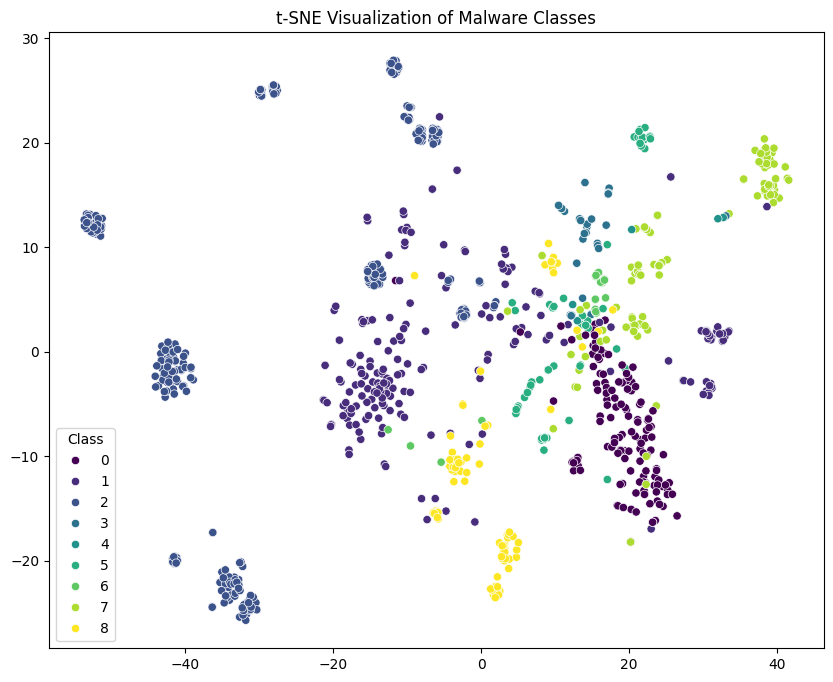

In [28]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

# 為了效能，我們抽取一部分數據來視覺化（例如 1000 筆）
X_embedded = TSNE(n_components=2, random_state=42).fit_transform(X_test_scaled[:1000])
y_subset = y_test_final_merged[:1000]

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=y_subset, palette='viridis', legend='full')
plt.title("t-SNE Visualization of Malware Classes")
plt.show()

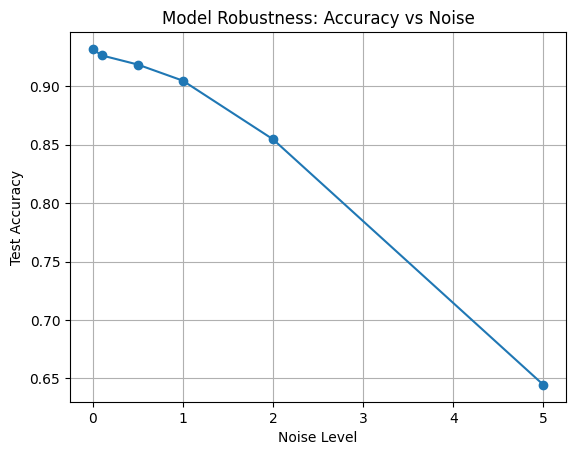

In [29]:
import numpy as np

noises = [0, 0.1, 0.5, 1.0, 2.0, 5.0]
accuracies = []

for n in noises:
    # 這裡模擬加入不同程度的雜訊
    X_test_noisy = X_test_scaled + np.random.normal(0, n, X_test_scaled.shape)
    score = knn.score(X_test_noisy, y_test_final_merged)
    accuracies.append(score)

plt.plot(noises, accuracies, marker='o')
plt.xlabel("Noise Level")
plt.ylabel("Test Accuracy")
plt.title("Model Robustness: Accuracy vs Noise")
plt.grid(True)
plt.show()

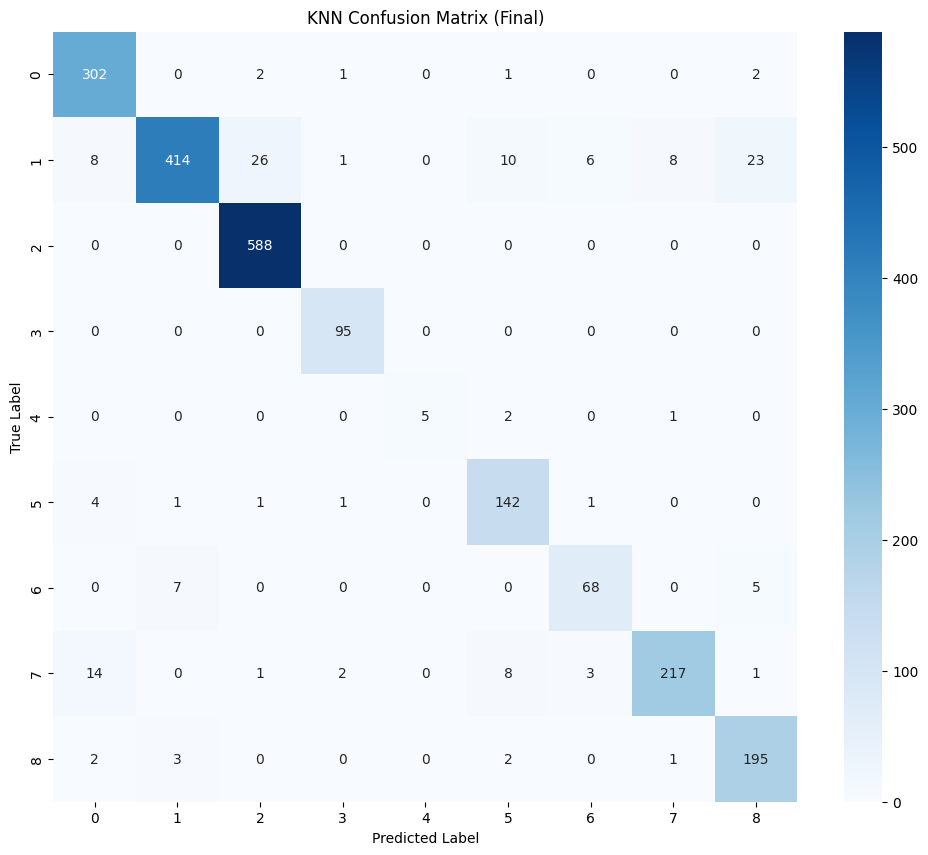

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_final_merged, y_test_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('KNN Confusion Matrix (Final)')
plt.show()